<a href="https://colab.research.google.com/github/nurahmi-tintyasusi-dev/DataScience_250401020035_NurahmiT/blob/main/Pertemuan9_Nurahmi_Tintyasusi_250401020035.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : NURAHMI TINTYASUSI

NIM : 250401020035

Kelas : IF401

Mata Kuliah : Data Science


---

In [5]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0=malignant, 1=benign

print("Shape data:", X.shape)
print("\nJumlah masing-masing kelas:")
print(y.value_counts().rename(index={0: 'Malignant', 1: 'Benign'}))

print("\nProporsi masing-masing kelas:")
print(
    y.value_counts(normalize=True)
     .rename(index={0: 'Malignant', 1: 'Benign'})
     .round(3)
)

Shape data: (569, 30)

Jumlah masing-masing kelas:
target
Benign       357
Malignant    212
Name: count, dtype: int64

Proporsi masing-masing kelas:
target
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


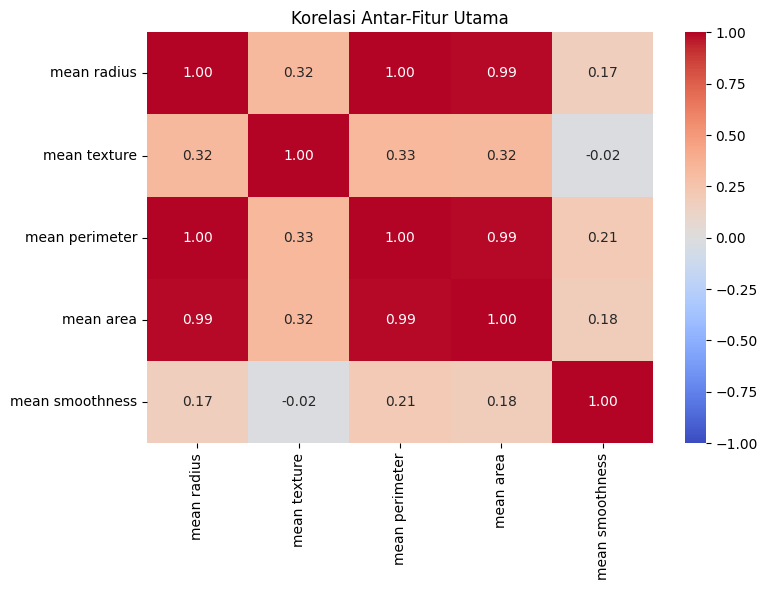

In [6]:
fitur_utama = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean smoothness'
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    X[fitur_utama].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Korelasi Antar-Fitur Utama')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

# Scaler hanya di-fit menggunakan data training
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Shape data training:", X_train.shape)
print("Shape data testing :", X_test.shape)

Shape data training: (455, 30)
Shape data testing : (114, 30)


In [8]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
})

coef_df['Nilai Absolut'] = coef_df['Koefisien'].abs()

coef_df = coef_df.sort_values(
    'Nilai Absolut',
    ascending=False
)

print("Sepuluh fitur paling berpengaruh:")
display(coef_df.head(10))

Sepuluh fitur paling berpengaruh:


,Fitur,Koefisien,Nilai Absolut
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


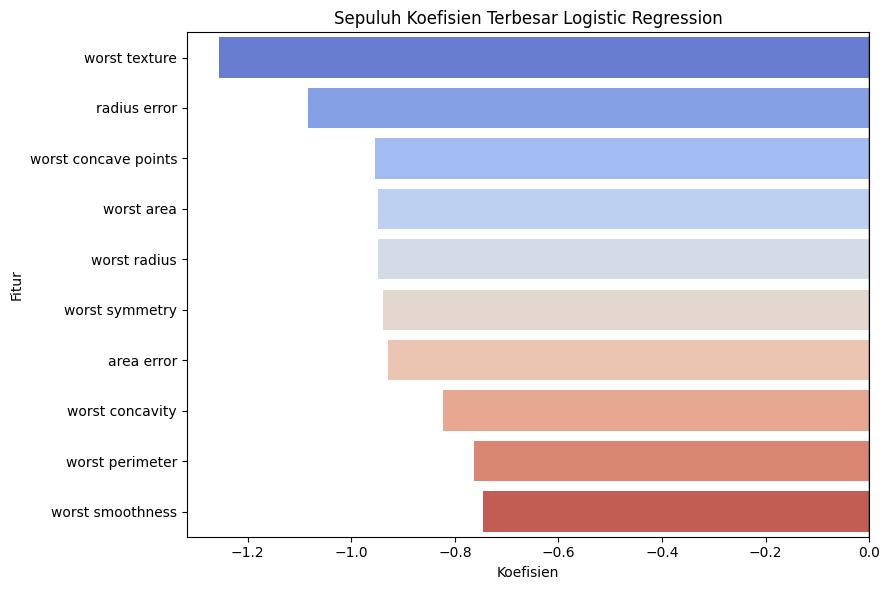

In [9]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=coef_df.head(10),
    x='Koefisien',
    y='Fitur',
    hue='Fitur',
    palette='coolwarm',
    legend=False
)

plt.axvline(0, color='black', linewidth=1)
plt.title('Sepuluh Koefisien Terbesar Logistic Regression')
plt.xlabel('Koefisien')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

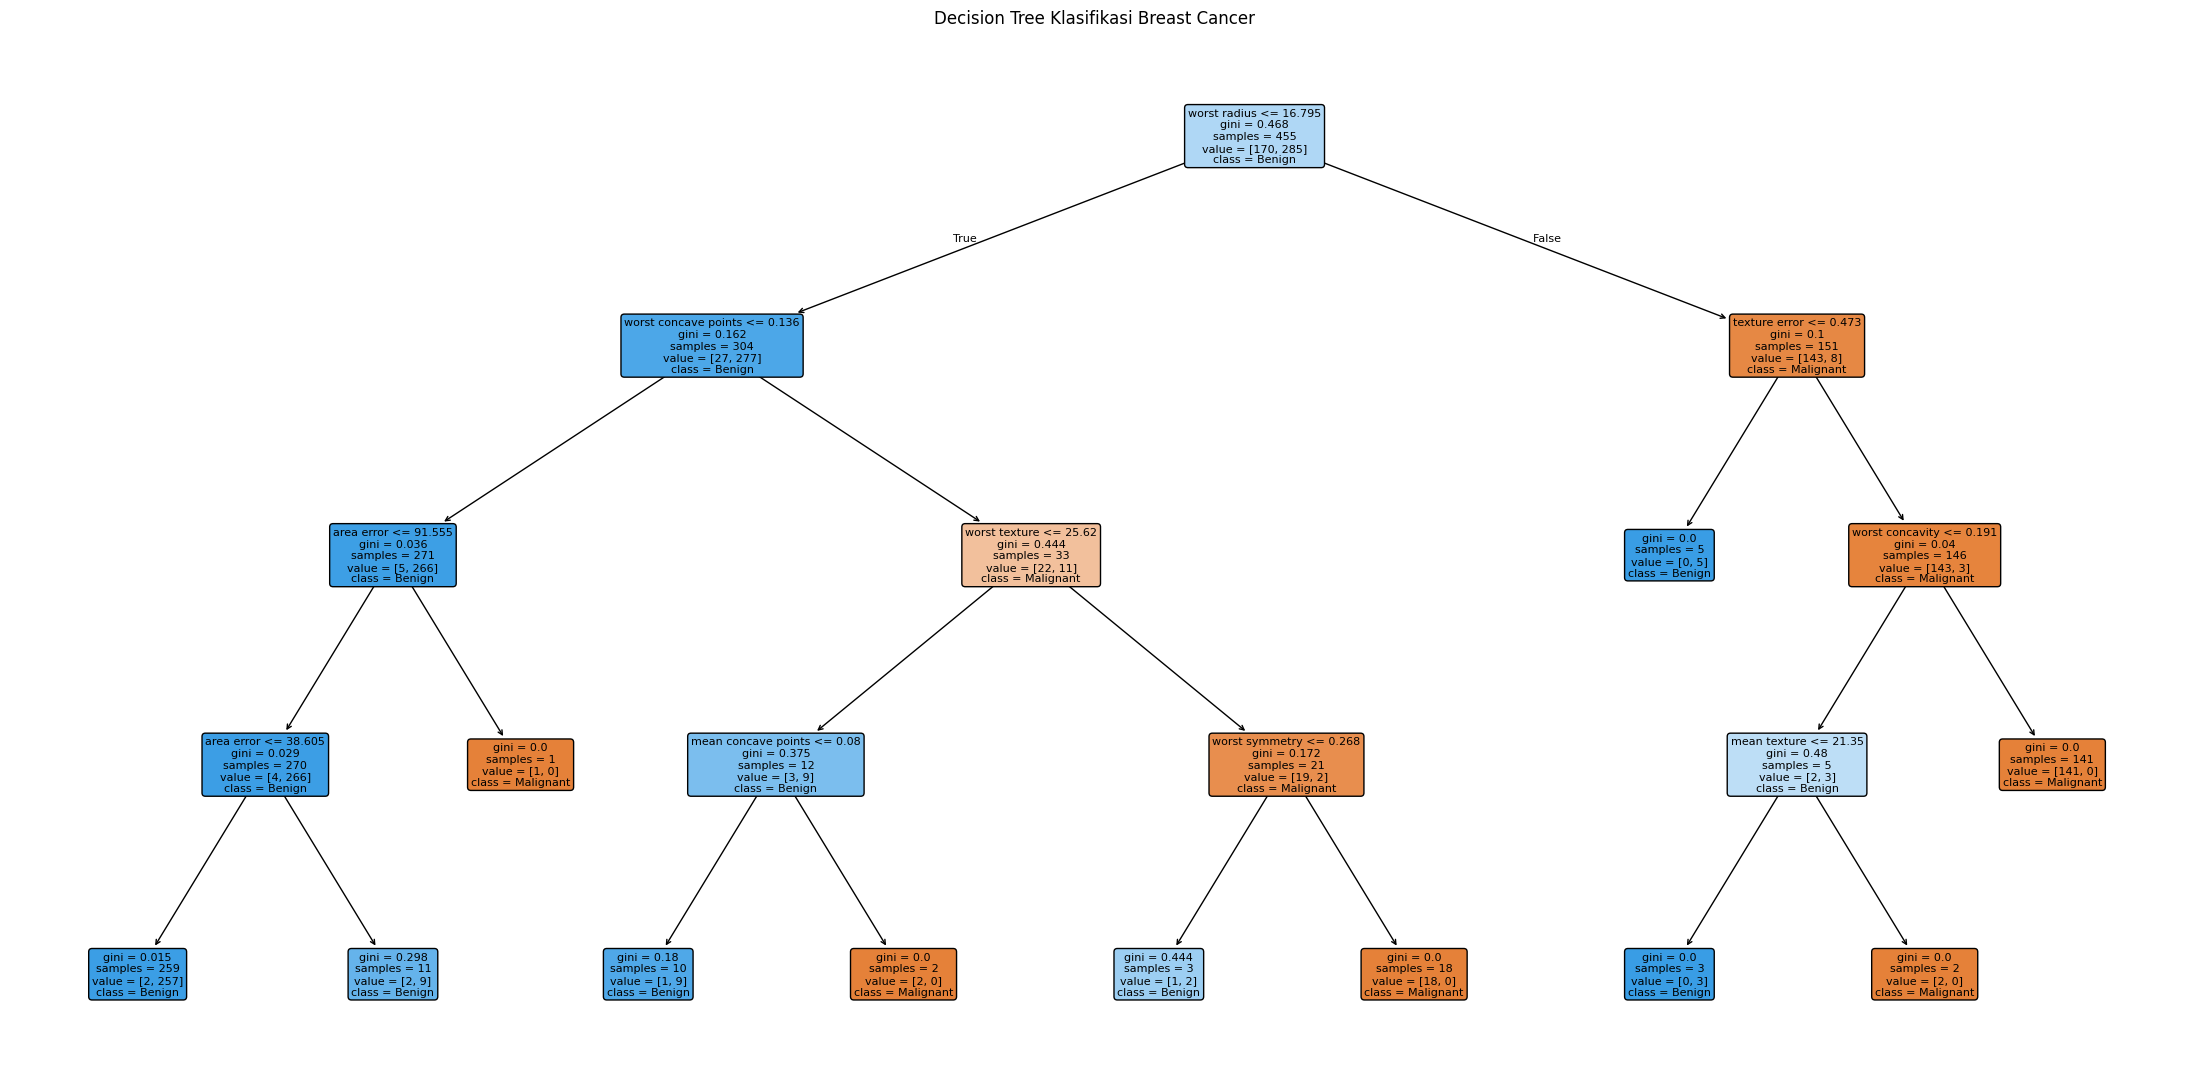

,Fitur,Importance
20,worst radius,0.733548
27,worst concave points,0.122028
11,texture error,0.045785
21,worst texture,0.032319
26,worst concavity,0.017161
7,mean concave points,0.013327
13,area error,0.012704
1,mean texture,0.011846
28,worst symmetry,0.011282
3,mean area,0.000000


In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Decision Tree menggunakan data asli tanpa scaling
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(22, 11))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Malignant', 'Benign'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Decision Tree Klasifikasi Breast Cancer')
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

display(importance_df.head(10))


=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy            : 0.982
Precision Malignant : 0.976
Recall Malignant    : 0.976
F1-Score Malignant  : 0.976

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy            : 0.939
Precision Malignant : 0.907
Recall Malignant    : 0.929
F1-Score Malignant  : 0.918


,Model,Accuracy,Precision Malignant,Recall Malignant,F1-Score Malignant
0,Logistic Regression,0.982,0.976,0.976,0.976
1,Decision Tree,0.939,0.907,0.929,0.918


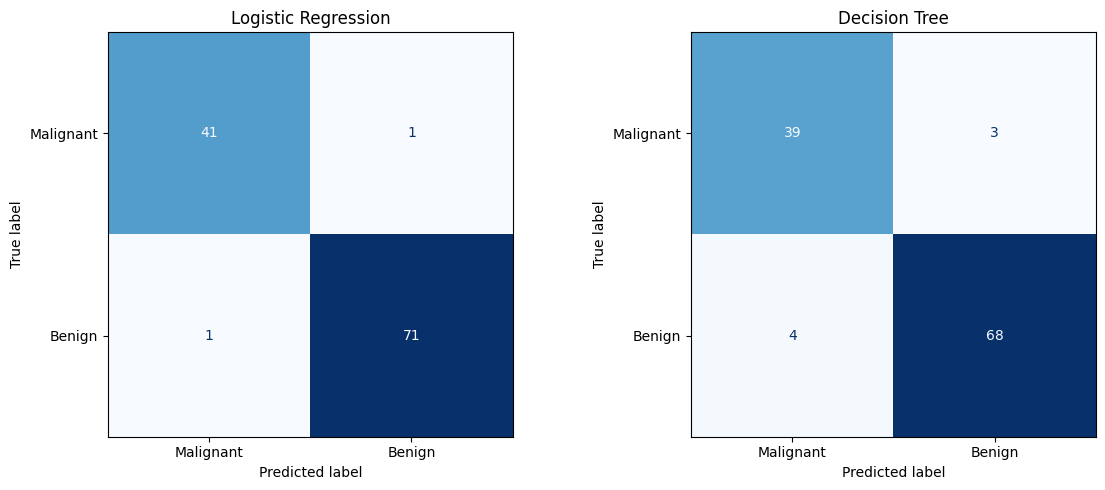

In [13]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

hasil_evaluasi = []

models_prediction = [
    ('Logistic Regression', y_pred_log),
    ('Decision Tree', y_pred_tree)
]

for name, y_pred in models_prediction:
    accuracy = accuracy_score(y_test, y_pred)

    # Malignant (0) dijadikan kelas positif
    precision_malignant = precision_score(
        y_test, y_pred, pos_label=0
    )
    recall_malignant = recall_score(
        y_test, y_pred, pos_label=0
    )
    f1_malignant = f1_score(
        y_test, y_pred, pos_label=0
    )

    hasil_evaluasi.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision Malignant': precision_malignant,
        'Recall Malignant': recall_malignant,
        'F1-Score Malignant': f1_malignant
    })

    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred, labels=[0, 1]))
    print(f"Accuracy            : {accuracy:.3f}")
    print(f"Precision Malignant : {precision_malignant:.3f}")
    print(f"Recall Malignant    : {recall_malignant:.3f}")
    print(f"F1-Score Malignant  : {f1_malignant:.3f}")

hasil_df = pd.DataFrame(hasil_evaluasi)
display(hasil_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, models_prediction):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=[0, 1],
        display_labels=['Malignant', 'Benign'],
        cmap='Blues',
        colorbar=False,
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Analisis Perbandingan Model

Berdasarkan hasil pengujian, **Logistic Regression memiliki Recall
malignant yang lebih tinggi**, yaitu sekitar **0,976**, sedangkan Decision
Tree memperoleh Recall malignant sekitar **0,929**. Artinya, Logistic
Regression berhasil mendeteksi sekitar 97,6% dari seluruh kasus kanker
ganas pada data pengujian.

Dari 42 pasien yang benar-benar termasuk kelas malignant, Logistic
Regression berhasil mengidentifikasi 41 pasien dan hanya melewatkan 1
pasien. Decision Tree mengidentifikasi 39 pasien malignant dan melewatkan
3 pasien sebagai benign. Dengan demikian, Logistic Regression mempunyai
jumlah false negative yang lebih rendah.

Recall menjadi metrik yang sangat kritis dalam diagnosis kanker karena


mengukur kemampuan model dalam menemukan seluruh pasien yang benar-benar
mengidap kanker ganas. False negative terjadi ketika pasien yang sebenarnya
mengidap kanker ganas diprediksi sebagai benign. Kesalahan ini berbahaya
karena dapat menyebabkan keterlambatan pemeriksaan lanjutan dan pengobatan.

Accuracy saja belum cukup untuk menilai model diagnosis medis. Dataset ini
memiliki lebih banyak kasus benign daripada malignant. Dalam kondisi kelas
yang tidak seimbang, model dapat memperoleh accuracy yang terlihat tinggi
meskipun masih gagal mendeteksi beberapa kasus kanker ganas. Oleh karena
itu, recall kelas malignant perlu menjadi perhatian utama, dengan tetap
mempertimbangkan precision dan F1-score.

Secara keseluruhan, Logistic Regression menunjukkan performa yang lebih
baik daripada Decision Tree. Logistic Regression mempunyai accuracy
98,2%, sedangkan Decision Tree mempunyai accuracy 93,9%. Selisih Recall
malignant kedua model sekitar 4,7 poin persentase dan Logistic Regression
menghasilkan dua false negative lebih sedikit. Pada data uji ini,
perbedaannya cukup berarti secara praktis karena setiap kasus kanker yang
terlewat dapat mempunyai konsekuensi serius. Namun, untuk menyatakan bahwa
perbedaannya signifikan secara statistik, diperlukan pengujian tambahan,
misalnya cross-validation dan uji perbandingan performa antarmodel.\